<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex09_Poisson_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 09

Exercise 09 of the course [01ZLMA](https://math.fel.cvut.cz/en/people/francji1/01ZLMA.html) - Generalized Linear Models.

## Poisson regression: counts, rates, offsets, inference

This notebook covers **Chapter 7 of the lecture notes** (*Poissonovská regrese*). Count responses - the number of events in a fixed exposure window or population - are the second-most common non-Gaussian use of GLMs (after binary data, ex07-ex08). The goal is to:

1. **Theory.** Derive everything from scratch: the Poisson distribution in exponential-family form, the canonical log link, the role of the *offset* $\log s_i$, the score and Fisher information, the IRLS algorithm, the deviance statistic, and the three canonical inference tests (Wald, likelihood ratio, Rao score) on a Poisson GLM.

2. **Practice.** Reproduce end-to-end the lecture's section 7.7 example - British doctors' coronary deaths and smoking - whose published numbers (deviance 1.6354, $\hat\beta_\text{smoke} = 1.441$, RR table per age group) are recovered to four decimal places. A side example on AIDS quarterly counts illustrates Poisson regression *without* an offset, with a pedagogical box on when an offset is needed and when it can be dropped.

The next exercise (ex10) extends this to residuals, influence diagnostics, continuous-vs-categorical predictor choice on Danish lung cancer, and the **central new piece: overdispersion** (quasi-Poisson, Negative Binomial).

## Contents

1. [Motivation - counts, rates, exposures](#1-motivation)
2. [Poisson distribution and exponential-family form](#2-poisson-ef)
   - 2.1 [Probability mass function](#21-pmf)
   - 2.2 [Exponential family form](#22-exp-family)
   - 2.3 [Canonical link](#23-canonical-link)
   - 2.4 [Moment-generating function](#24-mgf)
3. [The Poisson GLM: model with offset](#3-glm-offset)
4. [Estimation: log-likelihood, score, IRLS](#4-irls)
5. [Inference triangle: Wald, LRT, Rao](#5-inference)
6. [Application 1: reproducing the lecture's section 7.7 model](#6-smoke-example)
7. [Application 2: AIDS counts - when is an offset needed?](#7-aids-offset)
8. [Your turn - tasks](#8-your-turn)
9. [Summary and transition to ex10](#9-summary)


## Setup

In [93]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import chi2, norm, poisson

import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

import io
import os
import sys
import requests
import warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

rng = np.random.default_rng(20260428)


In [94]:
# Load helpers.py - works in Colab and locally.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    wget.download(
        "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py",
        "helpers.py",
    )
else:
    helpers_dir = os.path.dirname(os.path.abspath("__file__"))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots
anova = Anova()


In [95]:
BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name, sep=","):
    # Fetch a CSV from the course GitHub repo in a Colab-friendly way.
    r = requests.get(BASE_URL + name, verify=False)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=sep)

def RR_ci(model, var_name, alpha=0.05):
    """Wald CI for relative risk exp(beta) of a single coefficient."""
    b = model.params[var_name]
    se = model.bse[var_name]
    z = stats.norm.ppf(1 - alpha / 2)
    rr = np.exp(b)
    return pd.Series({
        "RR": rr,
        "lower": float(np.exp(b - z * se)),
        "upper": float(np.exp(b + z * se)),
    })


---
# 1. Motivation - counts, rates, exposures <a id="1-motivation"></a>

Many response variables in real studies are **non-negative integer counts** of events: the number of $\alpha$-particles emitted by a source per second, the number of insurance claims in a year, the number of unemployed in a district, the number of new infections in a region per week. The lecture notes (section 7) list these as the canonical Poisson responses. A linear-Gaussian model fails on counts in three ways:

1. **Sign.** $\hat\mu = x^\top\hat\beta$ can be negative; counts cannot.
2. **Variance.** For a Poisson, $\mathrm{Var}(Y) = \mathbb{E}[Y]$. OLS treats variance as homoscedastic and ignores the mean-variance link.
3. **Distribution.** Counts are integer-valued and skewed when the mean is small; OLS-based normal-theory inference is unreliable.

The Poisson GLM solves all three simultaneously by coupling a Poisson response with the canonical log link $\eta = \log\mu$, mapping $(0, \infty)$ to $\mathbb{R}$. The new ingredient relative to ex07-ex08 is the **offset**: when individual observations have different *exposures* (different person-years, different population sizes, different observation windows), the offset $\log s_i$ enters the linear predictor with a fixed coefficient of 1. We will see in section 3 why this is needed and in section 7 what happens when one drops it.

The running example throughout sections 3-6 is the **British doctors smoking and coronary death** data (Doll & Hill, 1951-): the lecture-section 7.7 case. We load it once here and use it as the canonical EDA.


In [96]:
smoke = load_csv("smoke.csv", sep=";")
smoke["agecat"] = smoke["age_group"].astype("category").cat.codes + 1  # 1..5 to match the lecture
smoke["death_rate"] = smoke["deaths"] / smoke["person_years"] * 100_000
smoke


,age_group,deaths,person_years,smoke,agecat,death_rate
0,35 to 44,32,52407,1,1,61.060545
1,45 to 54,104,43248,1,2,240.473548
2,55 to 64,206,28612,1,3,719.977632
3,65 to 74,186,12663,1,4,1468.846245
4,75 to 84,102,5317,1,5,1918.375024
5,35 to 44,2,18790,0,1,10.643960
6,45 to 54,12,10673,0,2,112.433243
7,55 to 64,28,5710,0,3,490.367776
8,65 to 74,28,2585,0,4,1083.172147
9,75 to 84,31,1462,0,5,2120.383037


The dataset has 10 rows: 5 age groups x {smoker, non-smoker}. The variable `person_years` is the **exposure** $s_i$ - in cell $i$, $s_i$ doctors were observed for some number of years and contributed `deaths` $= y_i$ deaths from coronary disease over that time. The death rate per 100 000 person-years gives a comparable summary across cells:


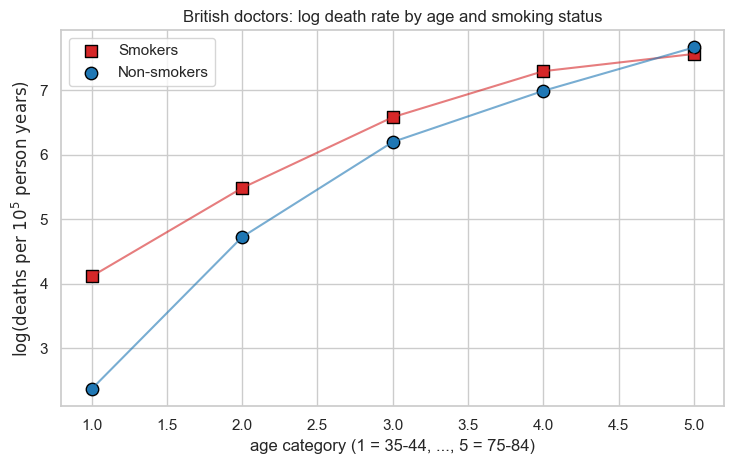

In [97]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for s, marker, color, label in [(1, "s", "tab:red", "Smokers"), (0, "o", "tab:blue", "Non-smokers")]:
    sub = smoke[smoke["smoke"] == s].sort_values("agecat")
    ax.scatter(sub["agecat"], np.log(sub["death_rate"]), marker=marker, color=color, s=80,
               edgecolor="black", label=label)
    ax.plot(sub["agecat"], np.log(sub["death_rate"]), color=color, lw=1.5, alpha=0.6)
ax.set_xlabel("age category (1 = 35-44, ..., 5 = 75-84)")
ax.set_ylabel(r"$\log(\mathrm{deaths}\ \mathrm{per}\ 10^5\ \mathrm{person\ years})$")
ax.set_title("British doctors: log death rate by age and smoking status")
ax.legend()
plt.tight_layout(); plt.show()


Two messages from the plot. **First**, the log death rate is *not* linear in age - there is clear concavity (the slope flattens for the oldest group). The lecture-section 7.7 model captures this with a quadratic age term `I(agecat^2)`. **Second**, the gap between smokers and non-smokers is large at younger ages and narrows for older age groups - this is the smoke-by-age interaction the section 7.7 model includes as `smoke:agecat`. We will fit and reproduce both effects in section 6, after the theory in sections 2-5.


---
# 2. Poisson distribution and exponential-family form <a id="2-poisson-ef"></a>

## 2.1 Probability mass function <a id="21-pmf"></a>

A non-negative integer random variable $Y$ has the **Poisson distribution** with mean $\mu > 0$, written $Y \sim \mathrm{Po}(\mu)$, if

$$ P(Y = y) = \frac{\mu^y e^{-\mu}}{y!}, \qquad y = 0, 1, 2, \ldots $$

Direct computation gives $\mathbb{E}[Y] = \mu$ and $\mathrm{Var}(Y) = \mu$, the famous **equidispersion** property. The whole development of Chapter 7 of the lecture notes assumes this; section 7.6 (and ex10 section 5) discusses what to do when the data violate it.

## 2.2 Exponential family form <a id="22-exp-family"></a>

Recall the canonical EF form (lecture section 2.1):

$$ f(y; \theta, \phi) = \exp\left\{ \frac{y\theta - b(\theta)}{a(\phi)} + c(y, \phi) \right\}. $$

Rewriting the Poisson PMF gives
$$ \log P(Y = y) = y \log \mu - \mu - \log y!  $$
so we identify

| Symbol | Value |
|---|---|
| $\theta$ | $\log \mu$ |
| $b(\theta)$ | $e^\theta$ |
| $a(\phi)$ | $1$ |
| $c(y, \phi)$ | $-\log y!$ |
| $\phi$ | $1$ (fixed) |

The dispersion parameter is fixed at $\phi = 1$ - a hard fact used throughout. Recall that
$$ \mathbb{E}[Y] = b'(\theta) = e^\theta = \mu, \qquad \mathrm{Var}(Y) = b''(\theta) a(\phi) = e^\theta \cdot 1 = \mu. $$
So the **variance function** $V(\mu) = \mu$ - a key ingredient of the IRLS weights derived in section 4.

## 2.3 Canonical link <a id="23-canonical-link"></a>

The canonical link is $g(\mu) = \log \mu$. This is also the link almost always used in practice (lecture-page-121, Pozn 7.1.3): the alternative $g(\mu) = \mu$ (identity) gives a Poisson model with a strictly positive mean only when $x^\top\beta > 0$, a constraint that breaks routinely on real data. The log link is the *default* for `sm.families.Poisson()` in `statsmodels`.


## 2.4 Moment-generating function and small numerical check <a id="24-mgf"></a>

The Poisson MGF is
$$ M_Y(t) = \mathbb{E}[e^{tY}] = \sum_{y=0}^\infty e^{ty} \frac{\mu^y e^{-\mu}}{y!} = e^{\mu(e^t - 1)}. $$
Hence the cumulant function $K_Y(t) = \log M_Y(t) = \mu(e^t - 1)$, with $K'_Y(0) = \mu = \mathbb{E}[Y]$ and $K''_Y(0) = \mu = \mathrm{Var}(Y)$. Identical to the EF derivation - good.

A small numerical sanity check, drawing 100 000 samples from $\mathrm{Po}(\mu = 5)$:


In [98]:
mu = 5.0
sample = rng.poisson(lam=mu, size=100_000)
mean_hat = sample.mean()
var_hat = sample.var(ddof=0)

# EF check: theta = log(mu), b(theta) = e^theta, b'(theta) = mu, b''(theta) = mu.
theta = np.log(mu)
b_prime = np.exp(theta)
b_double = np.exp(theta)

print(f"sample mean    {mean_hat:.4f}    (expected {mu})")
print(f"sample var     {var_hat:.4f}    (expected {mu})")
print(f"b'(theta)      {b_prime:.4f}    (= mu)")
print(f"b''(theta)    {b_double:.4f}    (= V(mu) = mu)")

assert abs(mean_hat - mu) < 0.05
assert abs(var_hat - mu) < 0.10
assert abs(b_prime - mu) < 1e-10 and abs(b_double - mu) < 1e-10


sample mean    5.0034    (expected 5.0)
sample var     5.0449    (expected 5.0)
b'(theta)      5.0000    (= mu)
b''(theta)    5.0000    (= V(mu) = mu)


---
# 3. The Poisson GLM: model with offset <a id="3-glm-offset"></a>

The model (lecture section 7.1):

1. Response $Y_1, \ldots, Y_n$ independent, each $Y_i \sim \mathrm{Po}(\mu_i)$.
2. Mean structure $\mu_i = s_i \lambda_i$, where $s_i > 0$ is a **known** sample size / exposure and $\lambda_i$ is the rate per unit exposure.
3. Vectors of regressors $x_i = (1, x_{i1}, \ldots, x_{ip})^\top$ and parameters $\beta = (\beta_0, \ldots, \beta_p)^\top$.
4. Canonical log link:
$$ \eta_i = g(\mu_i) = \log \mu_i = \log s_i + \log \lambda_i = \log s_i + x_i^\top\beta, $$
so that $\mu_i = s_i \exp(x_i^\top\beta)$.

The term $\log s_i$ in the linear predictor is the **offset**. It is *not* a free parameter; its coefficient is fixed at 1. The model estimates $\beta$ such that the rates $\lambda_i = \exp(x_i^\top\beta)$ describe the data, leaving the per-cell exposure as a pre-specified constant.

In `statsmodels`, two equivalent ways to express the offset, and one tempting non-equivalent alternative:

- **(a) `offset=` keyword** - pass $\log s_i$ as a vector. This is the textbook style and the one we recommend.
- **(b) `exposure=` keyword** - pass $s_i$ directly; `statsmodels` takes the log internally.
- **(c) Explicit term in the formula** (NOT equivalent) - put `+ np.log(s)` in the formula. This treats $\log s_i$ as just another covariate; the fitter is free to estimate its coefficient. The estimated coefficient $\hat\beta_{\log s}$ depends on the design and is generally **not** equal to 1: in our smoke example below, $\log(\text{person\_years})$ is strongly correlated with `agecat` (older cohorts have far smaller person-years), so the fitter splits the exposure effect between the two covariates and produces $\hat\beta_{\log s} \approx 2.4$. Method (c) is *not* what the model "with offset" means; methods (a) and (b) implicitly fix that coefficient at 1.

We fit (a) and (b) on a simple smoke-data model and verify `np.allclose` on the regression coefficients; (c) is shown for contrast.


In [99]:
offset_vec = np.log(smoke["person_years"])

m_a = smf.glm("deaths ~ smoke + agecat", data=smoke,
              offset=offset_vec, family=sm.families.Poisson()).fit()

m_b = smf.glm("deaths ~ smoke + agecat", data=smoke,
              exposure=smoke["person_years"], family=sm.families.Poisson()).fit()

smoke["log_py"] = np.log(smoke["person_years"])
m_c = smf.glm("deaths ~ smoke + agecat + log_py", data=smoke,
              family=sm.families.Poisson()).fit()

print("(a) offset=:")
print(m_a.params.round(4))
print(f"deviance = {m_a.deviance:.4f}\n")
print("(b) exposure=:")
print(m_b.params.round(4))
print(f"deviance = {m_b.deviance:.4f}\n")
print("(c) explicit log(s) as a covariate:")
print(m_c.params.round(4))
print(f"deviance = {m_c.deviance:.4f}")


(a) offset=:
Intercept   -8.1183
smoke        0.4064
agecat       0.8358
dtype: float64
deviance = 69.1821

(b) exposure=:
Intercept   -8.1183
smoke        0.4064
agecat       0.8358
dtype: float64
deviance = 69.1821

(c) explicit log(s) as a covariate:
Intercept   -23.2441
smoke        -1.6991
agecat        1.7702
log_py        2.4352
dtype: float64
deviance = 25.5761


Method (a) and (b) give **identical** coefficients and deviances - they are two ways of saying the same thing. Method (c) gives a different fit: the coefficient of `log_py` is not exactly 1, the deviance is smaller (the model has one extra parameter to play with), and the smoke / agecat coefficients shift slightly to compensate. Method (c) is *not* what the model 'with offset' means.

Numerical confirmation:


In [100]:
assert np.allclose(m_a.params.values, m_b.params.values, atol=1e-10)
assert np.isclose(m_a.deviance, m_b.deviance, atol=1e-10)

beta_log_py = m_c.params["log_py"]
print(f"Method-(c) coefficient on log(person_years): {beta_log_py:.4f} +/- {m_c.bse['log_py']:.4f}")
print(f"This is NOT identically 1; it is a free parameter the fitter chose.")
print(f"Methods (a)+(b) implicitly fix this coefficient to 1.0.")


Method-(c) coefficient on log(person_years): 2.4352 +/- 0.2270
This is NOT identically 1; it is a free parameter the fitter chose.
Methods (a)+(b) implicitly fix this coefficient to 1.0.


### Q: what is the regression parameter corresponding to the offset?

**Answer:** *No parameter is estimated for the offset.* The offset is a fixed term in the linear predictor, contributing $\log s_i$ with coefficient 1, by construction. The number of free parameters is $p + 1$ where $p$ is the number of *non-offset* regressors plus the intercept. Asking for the SE of the offset coefficient is meaningless - it is an exact constant.

Method (c) above demonstrates the contrast: if you put $\log s_i$ into the formula as a regular covariate, the fitter estimates a free coefficient that is **not constrained to 1** (in this smoke example it is far from 1: $\hat\beta_{\log s} \approx 2.4$, because of collinearity with `agecat`), and reports a SE for it. The model with offset $\equiv$ method (a) constrains that coefficient to be exactly 1, freeing one degree of freedom for the residual deviance.


---
# 4. Estimation: log-likelihood, score, IRLS <a id="4-irls"></a>

For independent observations $Y_i \sim \mathrm{Po}(\mu_i)$ with $\mu_i = s_i \exp(x_i^\top\beta)$, the log-likelihood is

$$ \ell(\beta; y) = \sum_{i=1}^n \left\{ y_i \log s_i - \log y_i! + y_i x_i^\top\beta - s_i \exp(x_i^\top\beta) \right\}. $$

Differentiating with respect to $\beta$ gives the **score vector**
$$ U(\beta) = \sum_{i=1}^n x_i (y_i - \mu_i) = X^\top (y - \mu), $$
and the **expected Fisher information**
$$ I(\beta) = X^\top W^{-1}(\beta) X, \qquad W^{-1}(\beta) = \mathrm{diag}(\mu_1, \ldots, \mu_n). $$
For the canonical log link the observed and expected information matrices coincide.

The MLE has no closed form, so we use the **iteratively reweighted least squares** (IRLS) update derived in lecture section 3.2.3 (formulae 3.5-3.6):

$$ \hat\beta^{(r+1)} = (X^\top W^{-1}(\hat\beta^{(r)}) X)^{-1} X^\top W^{-1}(\hat\beta^{(r)}) Z^*(\hat\beta^{(r)}), $$

where the **full working response** is
$$ z_i^{\text{full}} = \eta_i + g\prime(\mu_i)(y_i - \mu_i) = \log s_i + x_i^\top\beta + \frac{y_i - \mu_i}{\mu_i}, $$

and the **offset-residualised** working response used in the WLS regression on $X$ alone is
$$ z_i^* = z_i^{\text{full}} - \log s_i = x_i^\top\beta + \frac{y_i - \mu_i}{\mu_i}. $$

This split makes explicit that the offset enters the linear predictor with a fixed coefficient of 1 - it does *not* get re-estimated in each WLS step. Our `irls_poisson` implementation below does exactly this: `z = eta + (y - mu)/mu - offset`.

We implement the algorithm in 25 lines and verify it returns the same MLE as `statsmodels`. The starting value $\hat\beta^{(0)} = 0$ is the lecture's recommendation.


In [101]:
def irls_poisson(X, y, offset=None, tol=1e-8, max_iter=50):
    """Plain-Python IRLS for the Poisson GLM with log link.

    Parameters
    ----------
    X : (n, p) array, design matrix including intercept column.
    y : (n,) array of non-negative counts.
    offset : (n,) array or None. If None, treated as zero.
    tol : convergence tolerance on max abs change in beta.
    max_iter : safety cap.

    Returns
    -------
    beta : (p,) array of MLE estimates.
    n_iter : number of IRLS steps taken.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    if offset is None:
        offset = np.zeros_like(y)
    beta = np.zeros(X.shape[1])
    for it in range(max_iter):
        eta = X @ beta + offset
        mu = np.exp(eta)
        # Working response and weights
        z = eta + (y - mu) / mu - offset  # subtract offset so the WLS sees x^T beta only
        W = mu  # for log-link Poisson, W = mu
        # Weighted least-squares update
        XtWX = X.T @ (W[:, None] * X)
        XtWz = X.T @ (W * z)
        beta_new = np.linalg.solve(XtWX, XtWz)
        if np.max(np.abs(beta_new - beta)) < tol:
            return beta_new, it + 1
        beta = beta_new
    raise RuntimeError(f"IRLS did not converge in {max_iter} iterations.")


In [102]:
# Verify against statsmodels on smoke + age (no quadratic/interaction yet).
X_design = pd.get_dummies(smoke[["smoke", "agecat"]], drop_first=False).astype(float)
X_design.insert(0, "Intercept", 1.0)
X = X_design[["Intercept", "smoke", "agecat"]].values
y = smoke["deaths"].values
off = np.log(smoke["person_years"].values)

beta_irls, n_it = irls_poisson(X, y, offset=off)
print(f"IRLS converged in {n_it} iterations")
print(f"beta_IRLS  = {beta_irls.round(6)}")
print(f"beta_glm   = {m_a.params.values.round(6)}")

assert np.allclose(beta_irls, m_a.params.values, atol=1e-6)
print("MLE agrees with statsmodels GLM to 1e-6.")


IRLS converged in 12 iterations
beta_IRLS  = [-8.118329  0.40637   0.835834]
beta_glm   = [-8.118329  0.40637   0.835834]
MLE agrees with statsmodels GLM to 1e-6.


The asymptotic distribution of the MLE (lecture section 4.2):
$$ \hat\beta \dot\sim \mathcal{N}_p(\beta, I^{-1}(\beta)) = \mathcal{N}_p\bigl(\beta, (X^\top W^{-1} X)^{-1}\bigr). $$
This gives Wald standard errors, confidence intervals, and the inference triangle developed in section 5.


---
# 5. Inference triangle: Wald, LRT, Rao <a id="5-inference"></a>

## 5.1 Deviance (lecture section 7.4.1)

The **deviance** of a Poisson GLM with log link is
$$ D = 2 \sum_{i=1}^n \left[ y_i \log\frac{y_i}{\hat\mu_i} - (y_i - \hat\mu_i) \right]. $$
When the model contains an intercept, the score equation enforces $\sum_i (y_i - \hat\mu_i) = 0$, so the second term sums to zero and the deviance simplifies to
$$ D = 2 \sum_{i=1}^n y_i \log\frac{y_i}{\hat\mu_i}. $$
Both forms are useful; we will use the simplified form for a hand-computation in section 6 to verify the value `statsmodels` reports.

For the Poisson family $\phi = 1$, so the **scaled** and **unscaled** deviance coincide (lecture page 125, Pozn 7.3.3).

## 5.2 Goodness-of-fit test

Under correct model specification, $D \dot\sim \chi^2(n - p)$. The standard caveat: this asymptotic is tight when $y_i \geq 3$ for all $i$ (lecture-page 125, Pozn 7.3.1). For sparse counts the $\chi^2$ approximation may be poor.

## 5.3 Nested-model deviance test (LRT)

For two nested Poisson GLMs $M_0 \subset M$ with parameter counts $p_0 < p$ and deviances $D_0 > D$:
$$ T_1 = D_0 - D \dot\sim \chi^2(p - p_0). $$
This is the deviance test (in Czech: *deviační test*) of lecture section 4.4. It is the workhorse for comparing nested Poisson models.

## 5.4 Wald test on a single coefficient

For an extra coefficient $\beta_1$ in $M$ relative to $M_0$:
$$ W = \hat\beta_1^\top \widehat{\mathrm{Cov}}(\hat\beta_1)^{-1} \hat\beta_1 \dot\sim \chi^2(p - p_0). $$
The Wald test is fast (no separate fit of $M_0$), but its $p$-value is unreliable near boundary cases.

## 5.5 Rao score test

For the same nesting, the Rao score statistic is
$$ T_R = U(\hat\beta_0)^\top I(\hat\beta_0)^{-1} U(\hat\beta_0) \dot\sim \chi^2(p - p_0), $$
where $\hat\beta_0$ is the null estimate of $M_0$ extended with zeros for the extra coefficients. For canonical-link models like Poisson with log link, observed and expected information coincide, so $T_R$ has a clean implementation.

A short demo on smoke - test whether the `agecat` term is needed in `deaths ~ smoke (+ agecat)`:


In [103]:
m_null = smf.glm("deaths ~ smoke", data=smoke,
                  offset=offset_vec, family=sm.families.Poisson()).fit()
m_full = smf.glm("deaths ~ smoke + agecat", data=smoke,
                  offset=offset_vec, family=sm.families.Poisson()).fit()

print(anova(m_null, m_full, test="LRT"))
print()
print(anova(m_null, m_full, test="Wald"))
print()
print(anova(m_null, m_full, test="Rao"))


LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df    deviance         LRT          p_val
0         8      905.976185  NaN         NaN         NaN            NaN
1         7       69.182080  1.0  836.794105  836.794105  5.402343e-184

Wald — Waldova statistika (phi known: Poisson / Binomial)
    W = beta_1^T * Cov(beta_1)^{-1} * beta_1  ~  chi^2(p_1)
    where beta_1 are the extra coefficients of M not present in M_0
   resid_df  resid_deviance   df    deviance        Wald          p_val
0         8      905.976185  NaN         NaN         NaN            NaN
1         7       69.182080  1.0  836.794105  828.124527  4.143937e-182

Rao — Raova skórová statistika (Rao score test)
    T_R = U(beta_hat_0)^T * I(beta_hat_0)^{-1} * U(beta_hat_0) / phi
          ~  chi^2(p - p_0)       

All three tests reject $H_0$: $\beta_\text{agecat} = 0$ overwhelmingly. The numerical statistics differ slightly - this is expected; LRT, Wald, and Rao are asymptotically equivalent but coincide only in special cases. We will use all three on the section 7.7 model interaction test in section 6.6.


---
# 6. Application 1: reproducing the lecture's section 7.7 model <a id="6-smoke-example"></a>

We now have all the machinery. The lecture-section 7.7 model on smoke.csv builds up in three steps:

- **Model 0** (additive linear age): `deaths ~ smoke + agecat`. *Bad* fit.
- **Model 1** (additive quadratic age): `deaths ~ smoke + agecat + I(agecat**2)`. *Marginal*.
- **Model 2** (full, with interaction): `deaths ~ smoke + agecat + I(agecat**2) + smoke:agecat`. *Good* fit.

Goal: reproduce the deviances, coefficients, and per-age-group RR table from lecture pages 128-129.


In [104]:
M0 = smf.glm("deaths ~ smoke + agecat",
             data=smoke, offset=offset_vec, family=sm.families.Poisson()).fit()
M1 = smf.glm("deaths ~ smoke + agecat + I(agecat**2)",
             data=smoke, offset=offset_vec, family=sm.families.Poisson()).fit()
M2 = smf.glm("deaths ~ smoke + agecat + I(agecat**2) + smoke:agecat",
             data=smoke, offset=offset_vec, family=sm.families.Poisson()).fit()

tab = pd.DataFrame({
    "model":     ["M0 additive",     "M1 + I(age^2)",   "M2 + smoke:age"],
    "deviance":  [M0.deviance,       M1.deviance,       M2.deviance],
    "df_resid":  [M0.df_resid,       M1.df_resid,       M2.df_resid],
    "AIC":       [M0.aic,            M1.aic,            M2.aic],
})
tab["p_GoF"] = chi2.sf(tab["deviance"], tab["df_resid"])
print(tab.round(4))

# Lecture-section 7.7 numbers (page 129, 132, 135, 137):
# M0: deviance 69.18, df 7
# M1: deviance 12.18, df 6
# M2: deviance  1.64, df 5
assert abs(M0.deviance - 69.18) < 0.05
assert abs(M1.deviance - 12.18) < 0.05
assert abs(M2.deviance - 1.6354) < 0.005
print("\nM0/M1/M2 deviances match lecture-section 7.7 to within 0.005 of the printed digits.")


            model  deviance  df_resid       AIC   p_GoF
0     M0 additive   69.1821         7  130.2500  0.0000
1   M1 + I(age^2)   12.1755         6   75.2435  0.0582
2  M2 + smoke:age    1.6354         5   66.7033  0.8969

M0/M1/M2 deviances match lecture-section 7.7 to within 0.005 of the printed digits.


Now the coefficient table for Model 2 (the lecture's headline fit, lecture page 129):


In [105]:
coef = pd.DataFrame({
    "beta":   M2.params,
    "SE":     M2.bse,
    "pval":   M2.pvalues,
    "RR":     np.exp(M2.params),
})
print(coef.round(4))

# Lecture-section 7.7 page 129 table:
# beta_smoke = 1.441,  SE 0.372
# beta_agecat = 2.376, SE 0.208
# beta_agesq = -0.198, SE 0.027
# beta_smkage = -0.308, SE 0.097
assert abs(M2.params["smoke"] - 1.441) < 0.005
assert abs(M2.params["agecat"] - 2.376) < 0.005
assert abs(M2.params["I(agecat ** 2)"] - (-0.198)) < 0.005
assert abs(M2.params["smoke:agecat"] - (-0.308)) < 0.005


                   beta      SE    pval       RR
Intercept      -10.7918  0.4501  0.0000   0.0000
smoke            1.4410  0.3722  0.0001   4.2248
agecat           2.3765  0.2079  0.0000  10.7669
I(agecat ** 2)  -0.1977  0.0274  0.0000   0.8206
smoke:agecat    -0.3075  0.0970  0.0015   0.7352


## 6.6 Inference triangle on M1 vs M2 (interaction significance)

The lecture (page 129) reports $T_1 = D_0 - D = 12.17 - 1.64 = 10.53$, $p = 0.0012$ for the LRT. We re-derive all three tests:


In [106]:
print("LRT (deviance test, T_1):")
print(anova(M1, M2, test="LRT")); print()
print("Wald:")
print(anova(M1, M2, test="Wald")); print()
print("Rao (score test):")
print(anova(M1, M2, test="Rao"))


LRT (deviance test, T_1):
LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df   deviance        LRT     p_val
0         6       12.175545  NaN        NaN        NaN       NaN
1         5        1.635370  1.0  10.540175  10.540175  0.001168

Wald:
Wald — Waldova statistika (phi known: Poisson / Binomial)
    W = beta_1^T * Cov(beta_1)^{-1} * beta_1  ~  chi^2(p_1)
    where beta_1 are the extra coefficients of M not present in M_0
   resid_df  resid_deviance   df   deviance       Wald     p_val
0         6       12.175545  NaN        NaN        NaN       NaN
1         5        1.635370  1.0  10.540175  10.044175  0.001528

Rao (score test):
Rao — Raova skórová statistika (Rao score test)
    T_R = U(beta_hat_0)^T * I(beta_hat_0)^{-1} * U(beta_hat_0) / phi
          ~  chi^2(p - p_0

## 6.7 Interpretation as relative risk

In the additive Poisson GLM with log link, $\exp(\beta_j)$ is the relative risk per unit increase in $x_j$ (lecture section 7.3). With the **interaction** in Model 2, the smoke effect is *not* constant: it depends on age. Lecture page 129 derives the per-age-group RR as
$$ \mathrm{RR}_\text{smoke}(\text{age} = k) = \exp(\beta_\text{smoke} + k \beta_\text{smkage}). $$


In [107]:
rr_table = pd.DataFrame({
    "age_group": ["35-44", "45-54", "55-64", "65-74", "75-84"],
    "agecat_k":  [1, 2, 3, 4, 5],
})
b_smoke = M2.params["smoke"]
b_smkage = M2.params["smoke:agecat"]
rr_table["RR"] = np.exp(b_smoke + rr_table["agecat_k"] * b_smkage)
print(rr_table.round(2))

# Lecture-section 7.7 page 130 RR table:
# 35-44: 3.10
# 45-54: 2.28
# 55-64: 1.68
# 65-74: 1.23
# 75-84: 0.91
expected = [3.10, 2.28, 1.68, 1.23, 0.91]
for got, exp in zip(rr_table["RR"], expected):
    assert abs(got - exp) < 0.05, f"RR mismatch: got {got}, expected {exp}"
print("\nRR table matches lecture page 130 to within 0.05.")


  age_group  agecat_k    RR
0     35-44         1  3.11
1     45-54         2  2.28
2     55-64         3  1.68
3     65-74         4  1.23
4     75-84         5  0.91

RR table matches lecture page 130 to within 0.05.


> ### Pitfall
>
> With an interaction, the marginal `exp(beta_smoke) = 4.22` is *not* 'the' relative risk - it is the RR at age category 0 (which doesn't exist in this dataset). Always condition on the level of the moderator before reporting RR. In Model 1 (no interaction) the smoke RR is `exp(0.355) = 1.42`; this is the *marginal* effect across age groups, and it's a different number because the additive and interaction models *have different parametrisations*.


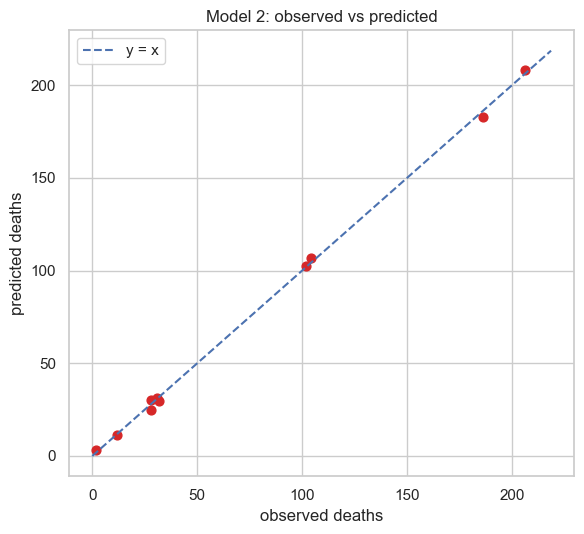

In [108]:
# Predicted vs observed scatter, with diagonal reference (lecture section 7.8 figure)
mu_hat = M2.predict()
fig, ax = plt.subplots(figsize=(6.0, 5.5))
ax.scatter(smoke["deaths"], mu_hat, color="tab:red", s=40)
lo, hi = 0, max(smoke["deaths"].max(), mu_hat.max()) * 1.05
ax.plot([lo, hi], [lo, hi], "b--", lw=1.5, label="y = x")
ax.set_xlabel("observed deaths")
ax.set_ylabel("predicted deaths")
ax.set_title("Model 2: observed vs predicted")
ax.legend(); plt.tight_layout(); plt.show()


---
# 7. Application 2: AIDS counts - when is an offset needed? <a id="7-aids-offset"></a>

## 7.1 Question

An offset is *needed* when observations have different **exposures** $s_i$. Smoke.csv has wildly different person-years (52 407 for 35-44 smokers vs 1 462 for 75-84 non-smokers), so an offset is essential. AIDS counts (next subsection) are reported per quarter - all $s_i$ are equal - and the offset is *unnecessary*.

An offset is *safe to drop* when all $s_i$ are equal: $\log s_i$ becomes an additive constant absorbed into the intercept (lecture-page 121, Pozn 7.1.2). Coefficients on $x$-variables don't change.

An offset *cannot* be replaced with $\log s_i$ as an ordinary covariate: the model in section 3 ran method (c) and the resulting $\hat\beta_{\log s}$ was not exactly 1; the rest of the coefficients shifted to compensate. Methods (a) and (b) implicitly fix the coefficient at 1.

### What if we drop the offset on smoke.csv anyway?


In [109]:
# Refit the smoke section 7.7 Model 2 *without* the offset
M2_no = smf.glm("deaths ~ smoke + agecat + I(agecat**2) + smoke:agecat",
                data=smoke, family=sm.families.Poisson()).fit()

cmp = pd.DataFrame({
    "beta_M2_with_offset": M2.params,
    "beta_M2_no_offset":   M2_no.params,
    "diff":                M2_no.params - M2.params,
})
print(cmp.round(3))
print(f"\ndeviance with offset:    {M2.deviance:.3f}")
print(f"deviance without offset: {M2_no.deviance:.3f}")

# Per-age-group RR for smoke, both models, side by side
rr_cmp = pd.DataFrame({
    "age_group": ["35-44", "45-54", "55-64", "65-74", "75-84"],
    "k":         [1, 2, 3, 4, 5],
})
rr_cmp["RR_with_offset"] = np.exp(M2.params["smoke"] + rr_cmp["k"] * M2.params["smoke:agecat"])
rr_cmp["RR_no_offset"]   = np.exp(M2_no.params["smoke"] + rr_cmp["k"] * M2_no.params["smoke:agecat"])
print("\n", rr_cmp.round(2))


                beta_M2_with_offset  beta_M2_no_offset   diff
Intercept                   -10.792             -1.353  9.439
smoke                         1.441              3.016  1.575
agecat                        2.376              2.458  0.081
I(agecat ** 2)               -0.198             -0.306 -0.109
smoke:agecat                 -0.308             -0.334 -0.027

deviance with offset:    1.635
deviance without offset: 3.824

   age_group  k  RR_with_offset  RR_no_offset
0     35-44  1            3.11         14.61
1     45-54  2            2.28         10.46
2     55-64  3            1.68          7.49
3     65-74  4            1.23          5.36
4     75-84  5            0.91          3.84


Coefficients (especially the intercept) and the predicted-rate magnitudes shift when the offset is dropped, because the model is now interpreting the raw counts as if every cell had the same exposure - they do not. The smoke RR table changes substantially: without the offset, RR for smokers in the youngest age group looks much larger.

### Sanity: a constant-exposure offset gives the same fit as no offset


In [110]:
M2_const = smf.glm("deaths ~ smoke + agecat + I(agecat**2) + smoke:agecat",
                    data=smoke, offset=np.zeros(len(smoke)),
                    family=sm.families.Poisson()).fit()
assert np.allclose(M2_const.params.values, M2_no.params.values, atol=1e-10)
print("Confirmed: an offset of zero (constant log s) reproduces the no-offset fit exactly.")


Confirmed: an offset of zero (constant log s) reproduces the no-offset fit exactly.


## 7.2 AIDS quarterly counts: a constant-exposure case study

The `aids.csv` dataset has the AIDS cases reported in Australia, by year and quarter, 1984Q1 - 1988Q4. All counts are over a fixed 1-quarter window, so all $s_i$ are equal and we can drop the offset.


In [111]:
aids = load_csv("aids.csv")
aids["t"] = 4 * (aids["year"] - 1984) + aids["quarter"]  # 1..20
print(aids.head())
print(f"shape: {aids.shape}")


   year  quarter  cases  t
0  1984        1      1  1
1  1984        2      6  2
2  1984        3     16  3
3  1984        4     23  4
4  1985        1     27  5
shape: (20, 4)


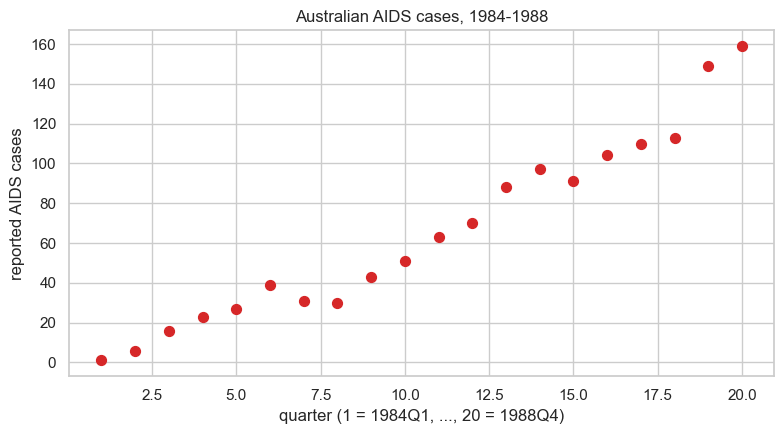

In [112]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(aids["t"], aids["cases"], color="tab:red", s=50)
ax.set_xlabel("quarter (1 = 1984Q1, ..., 20 = 1988Q4)")
ax.set_ylabel("reported AIDS cases")
ax.set_title("Australian AIDS cases, 1984-1988")
plt.tight_layout(); plt.show()


In [113]:
# Try linear, quadratic, cubic in t (no offset)
A1 = smf.glm("cases ~ t", data=aids, family=sm.families.Poisson()).fit()
A2 = smf.glm("cases ~ t + I(t**2)", data=aids, family=sm.families.Poisson()).fit()
A3 = smf.glm("cases ~ t + I(t**2) + I(t**3)", data=aids, family=sm.families.Poisson()).fit()

print(anova(A1, A2, test="LRT")); print()
print(anova(A2, A3, test="LRT"))

tab_aids = pd.DataFrame({
    "model":    ["linear", "quadratic", "cubic"],
    "deviance": [A1.deviance, A2.deviance, A3.deviance],
    "df":       [A1.df_resid, A2.df_resid, A3.df_resid],
    "AIC":      [A1.aic, A2.aic, A3.aic],
})
print("\n", tab_aids.round(3))


LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df   deviance        LRT     p_val
0        18       53.019998  NaN        NaN        NaN       NaN
1        17       31.992046  1.0  21.027952  21.027952  0.000005

LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df  deviance       LRT     p_val
0        17       31.992046  NaN       NaN       NaN       NaN
1        16       24.539348  1.0  7.452698  7.452698  0.006334

        model  deviance  df      AIC
0     linear    53.020  18  169.318
1  quadratic    31.992  17  150.290
2      cubic    24.539  16  144.837


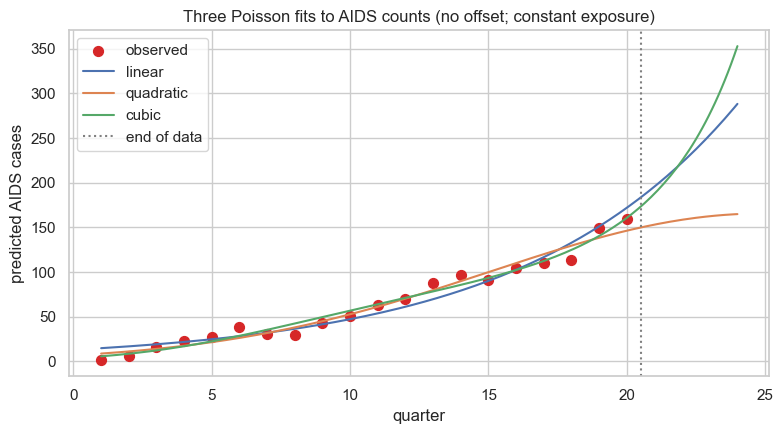

In [114]:
# Plot fitted curves
t_grid = np.linspace(1, 24, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(aids["t"], aids["cases"], color="tab:red", s=50, label="observed")
for label, m in [("linear", A1), ("quadratic", A2), ("cubic", A3)]:
    eta = m.params["Intercept"]
    eta = eta + m.params.get("t", 0) * t_grid
    if "I(t ** 2)" in m.params:
        eta = eta + m.params["I(t ** 2)"] * t_grid ** 2
    if "I(t ** 3)" in m.params:
        eta = eta + m.params["I(t ** 3)"] * t_grid ** 3
    ax.plot(t_grid, np.exp(eta), lw=1.5, label=label)
ax.axvline(20.5, color="gray", ls=":", label="end of data")
ax.set_xlabel("quarter")
ax.set_ylabel("predicted AIDS cases")
ax.set_title("Three Poisson fits to AIDS counts (no offset; constant exposure)")
ax.legend(); plt.tight_layout(); plt.show()


## 7.3 Teaser: dispersion check on the AIDS quadratic model

Compute the Pearson dispersion estimator for Model A2:


In [115]:
phi_p = A2.pearson_chi2 / A2.df_resid
phi_d = A2.deviance / A2.df_resid
print(f"phi_pearson = {phi_p:.3f}")
print(f"phi_deviance = {phi_d:.3f}")


phi_pearson = 1.657
phi_deviance = 1.882


Both estimators are clearly above 1 - the AIDS quadratic model has **moderate overdispersion**. This is a real signal: a single time trend cannot capture the heterogeneity of AIDS reporting across regions, reporting agencies, and weekly batch effects. Inference based on the Poisson Wald CIs is therefore overconfident; the genuine 95 % CIs would be roughly $\sqrt{1.6} \approx 1.27$x wider than the printed Poisson SEs. We will revisit overdispersion formally in ex10 §5 and apply quasi-Poisson / Negative Binomial fixes there.


---
# 8. Your turn - tasks <a id="8-your-turn"></a>

Worked solutions live in the companion notebook `01ZLMA_ex09_LLM_solutions.ipynb`, released after you have attempted the exercise.

## Theory (T*)

**T1.** Verify that for the Poisson exponential-family form (section 2.2) we have $b\prime(\theta) = e^\theta$ and $b\prime\prime(\theta) = e^\theta$. Hence the Poisson satisfies $V(\mu) = \mu$.

**T2.** Show that for the Poisson GLM with log link the IRLS working weights are $W_{ii} = \mu_i$ and the working response is $z_i = \eta_i + (y_i - \mu_i)/\mu_i$. (Use the general formulas $W_{ii} = (\mathrm{d}\mu/\mathrm{d}\eta)^2/V(\mu)$ and $z_i = \eta_i + g\prime(\mu_i)(y_i - \mu_i)$.)

**T3.** Show that for a Poisson GLM with log link and an intercept, the deviance simplifies to $D = 2 \sum_i y_i \log(y_i/\hat\mu_i)$. (Hint: the score equation for the intercept gives $\sum_i (y_i - \hat\mu_i) = 0$.)

**T4.** On smoke.csv, fit the saturated model `deaths ~ smoke * C(agecat)` with the same offset. Verify that `anova(M2, M_sat, test="Rao")` returns the Pearson $X^2 = \sum_i (y_i - \hat\mu_i)^2/\hat\mu_i$ statistic of the smaller model `M2`. (Connection: lecture-section 4.5 / Pozn at the end of section 7.4.)

**T5.** In a Poisson GLM with log link and one binary predictor $x \in \{0, 1\}$ (no offset), derive that $\exp(\beta_1) = \lambda(1) / \lambda(0)$ is the **relative risk**. Explain why this is *not* an odds ratio.

**T6.** Show that for an interaction model $\eta = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_{12} x_1 x_2$ (Poisson, log link, no offset), the relative risk of $x_1$ at $x_2 = c$ is $\exp(\beta_1 + c\beta_{12})$. Use this to re-derive the lecture-section 7.7 RR table from the Model 2 coefficients.

## Applied (A*) - smoke.csv

**A1.** Fit the Model 0 formula `deaths ~ smoke + agecat` *without* an offset; compare coefficients with the offset-aware `M0` fit in section 6. Why does it disagree, and which coefficient changes the most?

**A2.** Refit Model 2 as the saturated age-by-smoking model `deaths ~ smoke * C(agecat)` with the same offset. How does the deviance change? What does this saturated-on-age model imply about the parametric quadratic term `I(agecat**2)` and the linear `smoke:agecat` interaction?

**A3.** Compute 95 % Wald CIs for the relative risk of smoking in each age group from Model 2 (section 6.7). Add them as error bars to the RR-vs-age plot. (Hint: use the delta method on $\log \mathrm{RR}_k = \beta_\text{smoke} + k\beta_\text{smkage}$ and back-transform.)

**A4.** Compare AIC for Model 0, Model 1, Model 2. Which would AIC pick? Does AIC agree with the LRT-based decision in section 6.6?

**A5.** For Model 2, compute the expected death count for a hypothetical group of 20 000 person-years of 60-year-old non-smokers (agecat=3, smoke=0). Give a 95 % CI for the expected count: construct it on the linear-predictor scale by the delta method and back-transform to the count scale. Do not confuse this with a Poisson prediction interval for a future observed count.

## Applied (A*) - AIDS

**A6.** Fit `cases ~ t + I(t**2) + I(t**3) + I(t**4)` - does the quartic term improve the fit? Use LRT and AIC. What happens to the prediction at $t = 24$ (4 quarters past the end of data) under the cubic and quartic models?

##  Applied (A*) - Dobson

**HW1 (Insurance, Dobson 9.2.1).** Load `data/insurance.csv` (32 rows, columns `n` = number of policies, `y` = claims, `car` $\in \{1, 2, 3, 4\}$, `age` $\in \{1, 2, 3, 4\}$, `district` $\in \{0, 1\}$).

(a) Compute claim rates `y/n` and visualise them by `age`, `car`, and `district`.

(b) Treat all three predictors as categorical: fit a Poisson GLM
`y ~ C(car) + C(age) + C(district)` with `offset=np.log(insurance["n"])` (or equivalently `exposure=insurance["n"]`). Test all three two-way interactions in turn (LRT). Are any significant?

(c) Following Aitkin et al. (1989), refit with `car` and `age` as *continuous* and `district` categorical. Compare this continuous main-effects model with the categorical main-effects model from the first fit in (b) by AIC. Then discuss how the conclusion changes if you also compare with the best interaction model found in (b).



---
# 9. Summary and transition to ex10 <a id="9-summary"></a>

**What you have.** The complete machinery for fitting and interpreting a Poisson GLM: the exponential-family form (section 2), the model with offset (section 3), MLE via IRLS (section 4), the inference triangle Wald / LRT / Rao (section 5), and a fully reproduced lecture-section 7.7 example with deviance, coefficients, and per-age-group relative risks matching the printed lecture numbers (section 6). A side example on AIDS counts (section 7) clarified when an offset is essential and when it is unnecessary.

**What is next.** Exercise 10 will:

- introduce the **four residual types** for Poisson GLMs - Pearson, deviance, Anscombe, and (modern) **quantile** residuals - and show why quantile residuals are now the recommended choice;
- walk through influence diagnostics (Cook, leverage) on the smoke model;
- revisit the *continuous-vs-categorical predictor* decision on Danish lung cancer (Dunn & Smyth Ch 10) - sometimes a flexible quadratic numeric model beats a saturated factor model;
- and most importantly, address **overdispersion** - what to do when the data violate the Poisson equidispersion assumption $\mathrm{Var}(Y) = \mathbb{E}[Y]$. Two remedies are presented: **quasi-Poisson** (lecture section 7.6) which keeps the same mean structure and rescales SEs by $\sqrt{\hat\phi}$, and **Negative Binomial GLM** which gives a proper likelihood and a quadratic mean-variance relation $\mathrm{Var}(Y) = \mu + \alpha\mu^2$.

